# CVD Thesis — CNN-BiLSTM-Transformer + SHAP + Clinical Digital Twin

This notebook implements the base-paper-aligned preprocessing and a proposed CNN-BiLSTM-Transformer model, plus ablation, evaluation, SHAP XAI, and a clinical-state Digital Twin prototype.

In [ ]:
!pip -q install shap joblib

In [ ]:

import os, glob, json, random, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    classification_report, roc_curve, precision_recall_curve
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
import shap
import joblib

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

EPOCHS = 100
BATCH_SIZE = 256
LEARNING_RATE = 1e-3
VAL_SIZE = 0.20
TEST_SIZE = 0.20

# Run all core experiments in ONE execution.
# 1) Base CNN-LSTM without FE
# 2) Base CNN-LSTM with FE
# 3) Ablation CNN-BiLSTM with FE
# 4) Proposed CNN-BiLSTM-Transformer with FE
RUN_BASE_NO_FE = True
RUN_BASE_FE = True
RUN_BILSTM_FE = True
RUN_PROPOSED = True

# SHAP can be computationally expensive.
RUN_SHAP = True
SHAP_BACKGROUND = 50
SHAP_SAMPLES = 100

# Save everything to this folder.
OUT_DIR = "cvd_thesis_results" if not os.path.exists("/content") else "/content/cvd_thesis_results"
os.makedirs(OUT_DIR, exist_ok=True)

print("TensorFlow:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))



TensorFlow: 2.20.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:

REQUIRED = {
    "age","gender","height","weight","ap_hi","ap_lo",
    "cholesterol","gluc","smoke","alco","active","cardio"
}

def find_cardio_csv():
    candidates = ["cardio_train.csv"] + glob.glob("**/*.csv", recursive=True) + glob.glob("/content/**/*.csv", recursive=True)
    candidates = list(dict.fromkeys(candidates))
    for p in candidates:
        try:
            df0 = pd.read_csv(p, sep=";", nrows=5)
            if REQUIRED.issubset(set(df0.columns)):
                return p
        except Exception:
            pass
        try:
            df0 = pd.read_csv(p, sep=",", nrows=5)
            if REQUIRED.issubset(set(df0.columns)):
                return p
        except Exception:
            pass
    return None

DATA_PATH = find_cardio_csv()

if DATA_PATH is None:
    raise FileNotFoundError(
        "Kaggle cardio_train.csv not found in /content. "
        "Upload the CSV to Colab and run this cell again."
    )

# Kaggle's common cardio_train.csv uses semicolon separator.
try:
    df = pd.read_csv(DATA_PATH, sep=";")
    if not REQUIRED.issubset(set(df.columns)):
        df = pd.read_csv(DATA_PATH)
except Exception:
    df = pd.read_csv(DATA_PATH)

print("Dataset:", DATA_PATH)
print("Shape before cleaning:", df.shape)
print(df.head())



Dataset: /content/cardio_train.csv
Shape before cleaning: (70000, 13)
   id    age  gender  height  weight  ap_hi  ap_lo  cholesterol  gluc  smoke  \
0   0  18393       2     168    62.0    110     80            1     1      0   
1   1  20228       1     156    85.0    140     90            3     1      0   
2   2  18857       1     165    64.0    130     70            3     1      0   
3   3  17623       2     169    82.0    150    100            1     1      0   
4   4  17474       1     156    56.0    100     60            1     1      0   

   alco  active  cardio  
0     0       1       0  
1     0       1       1  
2     0       0       1  
3     0       1       1  
4     0       0       0  


In [ ]:

df = df.copy()

# Remove duplicate rows.
df = df.drop_duplicates().reset_index(drop=True)

# Convert age from days to years when the raw Kaggle format is used.
# The paper reports age in years in its descriptive statistics.
if df["age"].max() > 100:
    df["age"] = df["age"] / 365.25

# Paper-reported engineered features:
# blood_diff = ap_hi - ap_lo
# BMI = weight / height^2
# obese from BMI
# hypertense from blood pressure
df["blood_diff"] = df["ap_hi"] - df["ap_lo"]
df["BMI"] = df["weight"] / ((df["height"] / 100.0) ** 2)
df["obese"] = (df["BMI"] >= 30).astype(int)
df["hypertense"] = (
    (df["ap_hi"] >= 140) | (df["ap_lo"] >= 90)
).astype(int)

# The paper explicitly states that blood_diff values above 80
# were removed as uncommon. We also remove physiologically invalid
# negative differences.
before = len(df)
df = df[df["blood_diff"].between(0, 80)].copy()
df = df.replace([np.inf, -np.inf], np.nan).dropna().reset_index(drop=True)
print("Rows removed by cleaning:", before - len(df))
print("Shape after cleaning:", df.shape)

# Save cleaned data.
df.to_csv(os.path.join(OUT_DIR, "cleaned_engineered_dataset.csv"), index=False)



Rows removed by cleaning: 1960
Shape after cleaning: (68040, 17)


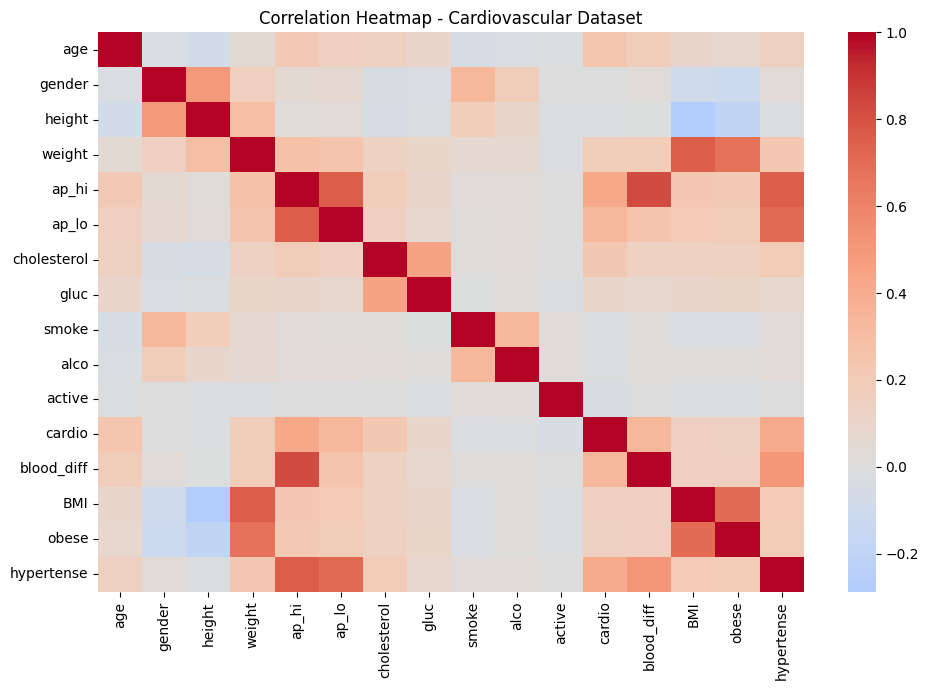

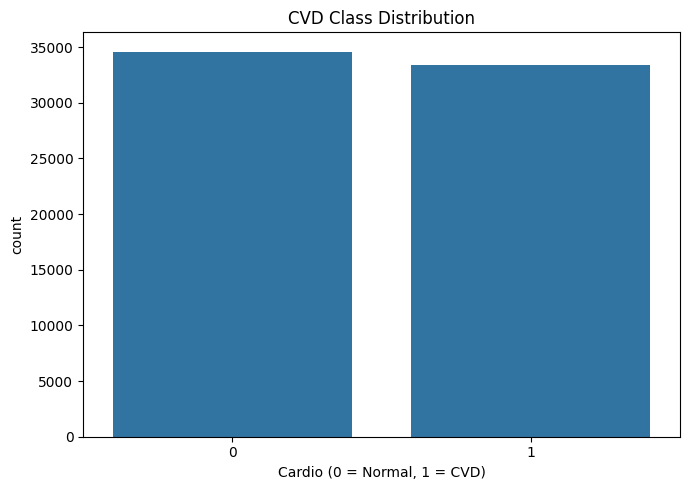

In [ ]:

plt.figure(figsize=(10, 7))
sns.heatmap(
    df.drop(columns=["id"], errors="ignore").corr(numeric_only=True),
    cmap="coolwarm", center=0
)
plt.title("Correlation Heatmap - Cardiovascular Dataset")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "correlation_heatmap.png"), dpi=300)
plt.show()

plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="cardio")
plt.title("CVD Class Distribution")
plt.xlabel("Cardio (0 = Normal, 1 = CVD)")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "class_distribution.png"), dpi=300)
plt.show()



In [ ]:

BASE_FEATURES = [
    "age","gender","height","weight","ap_hi","ap_lo",
    "cholesterol","gluc","smoke","alco","active"
]

FE_FEATURES = BASE_FEATURES + [
    "blood_diff","BMI","obese","hypertense"
]

TARGET = "cardio"

def prepare_data(features):
    X = df[features].astype(np.float32).values
    y = df[TARGET].astype(np.int32).values

    # Fixed stratified 80/20 test split.
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=TEST_SIZE,
        random_state=SEED,
        stratify=y
    )

    # IMPORTANT: fit scaler only on training data to avoid leakage.
    scaler = MinMaxScaler()
    X_train = scaler.fit_transform(X_train).astype(np.float32)
    X_test = scaler.transform(X_test).astype(np.float32)

    # CNN/LSTM expects a sequence. Here each clinical feature is treated
    # as one timestep with one channel: (samples, features, 1).
    X_train_seq = X_train[..., np.newaxis]
    X_test_seq = X_test[..., np.newaxis]

    return X_train, X_test, X_train_seq, X_test_seq, y_train, y_test, scaler



In [ ]:

def make_callbacks(name):
    return [
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=15,
            restore_best_weights=True,
            verbose=1
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=6,
            min_lr=1e-6,
            verbose=1
        ),
        keras.callbacks.ModelCheckpoint(
            os.path.join(OUT_DIR, f"{name}.keras"),
            monitor="val_loss",
            save_best_only=True,
            verbose=0
        )
    ]



In [ ]:

def conv_block(x, filters=64, kernel_size=3, dropout=0.20):
    x = layers.Conv1D(filters, kernel_size, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(pool_size=2, padding="same")(x)
    x = layers.Dropout(dropout)(x)
    return x

def build_cnn_lstm(input_shape):
    inp = layers.Input(shape=input_shape, name="clinical_input")

    x = conv_block(inp, 64, 3, 0.20)
    x = layers.Conv1D(128, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.20)(x)

    x = layers.LSTM(64, return_sequences=True)(x)
    x = layers.LSTM(32)(x)

    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.30)(x)
    out = layers.Dense(1, activation="sigmoid", name="cvd_probability")(x)

    model = Model(inp, out, name="CNN_LSTM")
    return model

def build_cnn_bilstm(input_shape):
    inp = layers.Input(shape=input_shape, name="clinical_input")

    x = conv_block(inp, 64, 3, 0.20)
    x = layers.Conv1D(128, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.20)(x)

    x = layers.Bidirectional(
        layers.LSTM(64, return_sequences=True)
    )(x)
    x = layers.Bidirectional(
        layers.LSTM(32, return_sequences=False)
    )(x)

    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.30)(x)
    out = layers.Dense(1, activation="sigmoid")(x)

    return Model(inp, out, name="CNN_BiLSTM")

def transformer_encoder(x, num_heads=4, key_dim=16, ff_dim=128, dropout=0.15):
    # Self-attention
    attn = layers.MultiHeadAttention(
        num_heads=num_heads,
        key_dim=key_dim,
        dropout=dropout
    )(x, x)

    x = layers.Add()([x, attn])
    x = layers.LayerNormalization(epsilon=1e-6)(x)

    # Feed-forward network
    ff = layers.Dense(ff_dim, activation="gelu")(x)
    ff = layers.Dropout(dropout)(ff)
    ff = layers.Dense(x.shape[-1])(ff)

    x = layers.Add()([x, ff])
    x = layers.LayerNormalization(epsilon=1e-6)(x)
    return x

def build_cnn_bilstm_transformer(input_shape):
    inp = layers.Input(shape=input_shape, name="clinical_input")

    # CNN feature extraction
    x = conv_block(inp, 64, 3, 0.20)
    x = layers.Conv1D(128, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.20)(x)

    # Bidirectional sequence modeling
    x = layers.Bidirectional(
        layers.LSTM(64, return_sequences=True)
    )(x)

    # Transformer self-attention
    x = transformer_encoder(
        x,
        num_heads=4,
        key_dim=16,
        ff_dim=128,
        dropout=0.15
    )

    # Second attention block for deeper representation
    x = transformer_encoder(
        x,
        num_heads=4,
        key_dim=16,
        ff_dim=128,
        dropout=0.15
    )

    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.35)(x)
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.25)(x)
    out = layers.Dense(1, activation="sigmoid", name="cvd_probability")(x)

    return Model(inp, out, name="CNN_BiLSTM_Transformer")

def compile_model(model):
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
        loss="binary_crossentropy",
        metrics=[
            keras.metrics.BinaryAccuracy(name="accuracy"),
            keras.metrics.Precision(name="precision"),
            keras.metrics.Recall(name="recall"),
            keras.metrics.AUC(name="auc")
        ]
    )
    return model



In [ ]:

results = []
trained_models = {}
test_sets = {}
histories = {}

def train_and_evaluate(model_name, builder, features):
    print("\n" + "="*80)
    print("RUNNING:", model_name)
    print("="*80)

    X_train, X_test, X_train_seq, X_test_seq, y_train, y_test, scaler = prepare_data(features)

    model = compile_model(builder(X_train_seq.shape[1:]))

    model.summary()

    history = model.fit(
        X_train_seq, y_train,
        validation_split=VAL_SIZE,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=make_callbacks(model_name),
        verbose=1,
        shuffle=True
    )

    prob = model.predict(X_test_seq, batch_size=BATCH_SIZE, verbose=0).ravel()
    pred = (prob >= 0.50).astype(int)

    metrics = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall": recall_score(y_test, pred, zero_division=0),
        "F1": f1_score(y_test, pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_test, prob),
        "PR_AUC": average_precision_score(y_test, prob)
    }

    print("\n", classification_report(y_test, pred, digits=4))
    print("Metrics:", metrics)

    # Save artifacts.
    joblib.dump(scaler, os.path.join(OUT_DIR, f"{model_name}_scaler.pkl"))
    np.save(os.path.join(OUT_DIR, f"{model_name}_test_prob.npy"), prob)
    np.save(os.path.join(OUT_DIR, f"{model_name}_test_y.npy"), y_test)

    trained_models[model_name] = model
    test_sets[model_name] = (X_test_seq, y_test, prob, pred, features)
    histories[model_name] = history.history

    pd.DataFrame([metrics]).to_csv(
        os.path.join(OUT_DIR, f"{model_name}_metrics.csv"),
        index=False
    )

    return metrics



In [ ]:

if RUN_BASE_NO_FE:
    results.append(
        train_and_evaluate(
            "01_Base_CNN_LSTM_No_FE",
            build_cnn_lstm,
            BASE_FEATURES
        )
    )

if RUN_BASE_FE:
    results.append(
        train_and_evaluate(
            "02_Base_CNN_LSTM_FE",
            build_cnn_lstm,
            FE_FEATURES
        )
    )

if RUN_BILSTM_FE:
    results.append(
        train_and_evaluate(
            "03_CNN_BiLSTM_FE",
            build_cnn_bilstm,
            FE_FEATURES
        )
    )

if RUN_PROPOSED:
    results.append(
        train_and_evaluate(
            "04_Proposed_CNN_BiLSTM_Transformer_FE",
            build_cnn_bilstm_transformer,
            FE_FEATURES
        )
    )

results_df = pd.DataFrame(results)
results_df.to_csv(os.path.join(OUT_DIR, "ALL_MODEL_RESULTS.csv"), index=False)

print("\nFINAL MODEL COMPARISON")
display(results_df.sort_values("Accuracy", ascending=False))




RUNNING: 01_Base_CNN_LSTM_No_FE


Model: "CNN_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ clinical_input (InputLayer)     │ (None, 11, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 11, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 11, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 6, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 6, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 6, 128)         │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 6, 128)         │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 6, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 6, 64)          │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cvd_probability (Dense)         │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 89,729 (350.50 KB)

 Trainable params: 89,345 (349.00 KB)

...

 Total params: 282,625 (1.08 MB)

 Trainable params: 282,241 (1.08 MB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/100
171/171 ━━━━━━━━━━━━━━━━━━━━ 15s 33ms/step - accuracy: 0.7056 - auc: 0.7581 - loss: 0.5868 - precision: 0.7260 - recall: 0.6433 - val_accuracy: 0.5072 - val_auc: 0.6783 - val_loss: 0.9520 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 2/100
171/171 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - accuracy: 0.7222 - auc: 0.7781 - loss: 0.5664 - precision: 0.7514 - recall: 0.6491 - val_accuracy: 0.5072 - val_auc: 0.7264 - val_loss: 0.8042 - val_precision: 0.5000 - val_recall: 1.8639e-04 - learning_rate: 0.0010
Epoch 3/100
171/171 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.7237 - auc: 0.7824 - loss: 0.5624 - precision: 0.7515 - recall: 0.6537 - val_accuracy: 0.6812 - val_auc: 0.7859 - val_loss: 0.6029 - val_precision: 0.8261 - val_recall: 0.4472 - learning_rate: 0.0010
Epoch 4/100
171/171 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - accuracy: 0.7251 - auc: 0.7840 - loss: 0.5607 - precision: 0.7545 - recall: 0.6527 - val_accuracy: 0.7221 - val_auc: 0.7947 - v

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,01_Base_CNN_LSTM_No_FE,0.736405,0.756663,0.683463,0.718203,0.799363,0.778164
1,02_Base_CNN_LSTM_FE,0.734127,0.754899,0.679725,0.715342,0.797529,0.776502
3,04_Proposed_CNN_BiLSTM_Transformer_FE,0.732804,0.759259,0.668212,0.710832,0.796422,0.777736
2,03_CNN_BiLSTM_FE,0.732143,0.762645,0.660586,0.707956,0.796861,0.777163


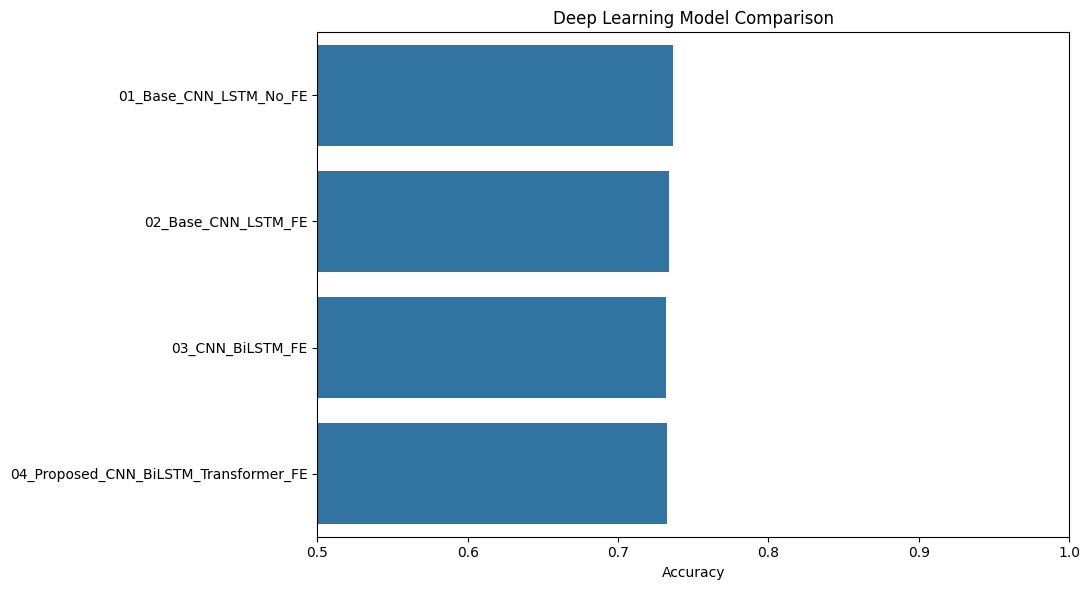

In [ ]:

plt.figure(figsize=(11, 6))
sns.barplot(data=results_df, x="Accuracy", y="Model")
plt.xlim(0.50, 1.00)
plt.xlabel("Accuracy")
plt.ylabel("")
plt.title("Deep Learning Model Comparison")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "model_accuracy_comparison.png"), dpi=300)
plt.show()



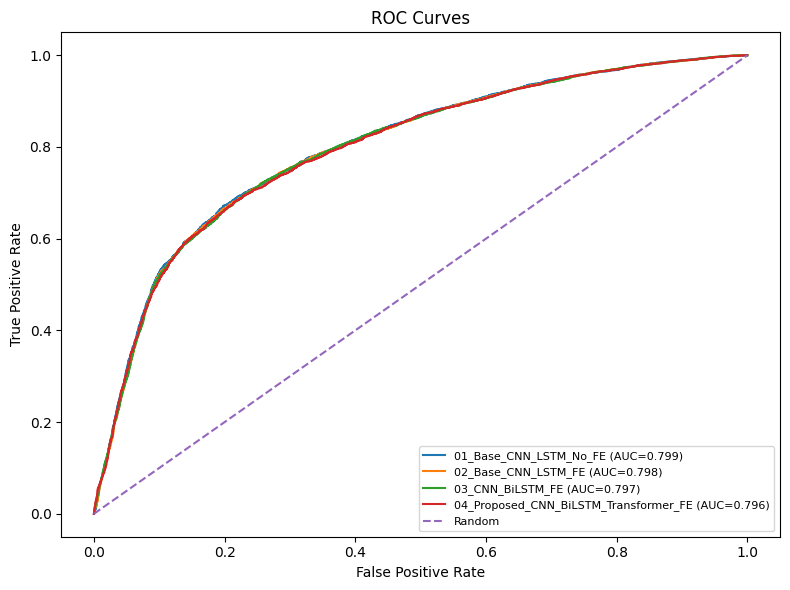

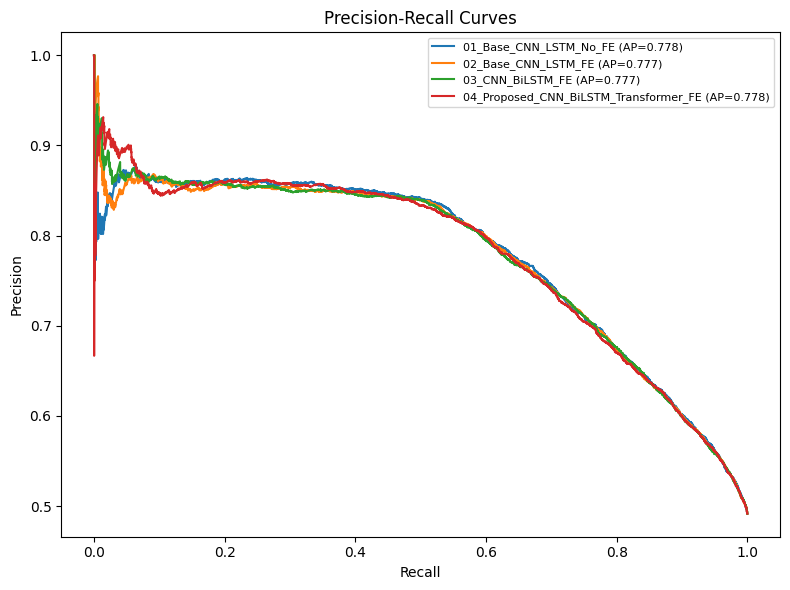

In [ ]:

plt.figure(figsize=(8, 6))
for name, (Xte, yte, prob, pred, features) in test_sets.items():
    fpr, tpr, _ = roc_curve(yte, prob)
    auc = roc_auc_score(yte, prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")
plt.plot([0,1], [0,1], "--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "ROC_comparison.png"), dpi=300)
plt.show()

plt.figure(figsize=(8, 6))
for name, (Xte, yte, prob, pred, features) in test_sets.items():
    precision, recall, _ = precision_recall_curve(yte, prob)
    ap = average_precision_score(yte, prob)
    plt.plot(recall, precision, label=f"{name} (AP={ap:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves")
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "PR_comparison.png"), dpi=300)
plt.show()



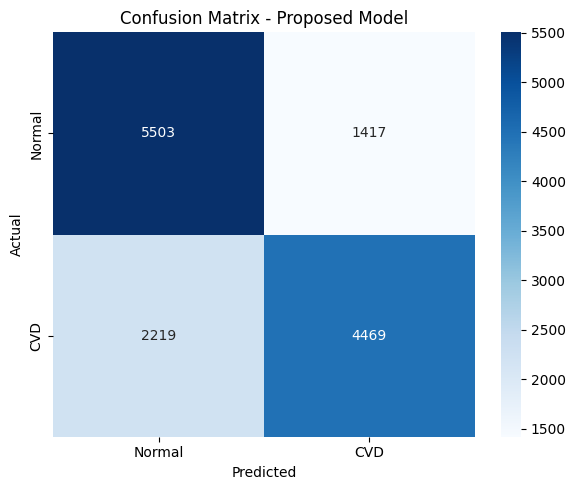

In [ ]:

FINAL_NAME = "04_Proposed_CNN_BiLSTM_Transformer_FE"

if FINAL_NAME in test_sets:
    Xte, yte, prob, pred, final_features = test_sets[FINAL_NAME]
    cm = confusion_matrix(yte, pred)

    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=["Normal","CVD"],
        yticklabels=["Normal","CVD"]
    )
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix - Proposed Model")
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, "proposed_confusion_matrix.png"), dpi=300)
    plt.show()



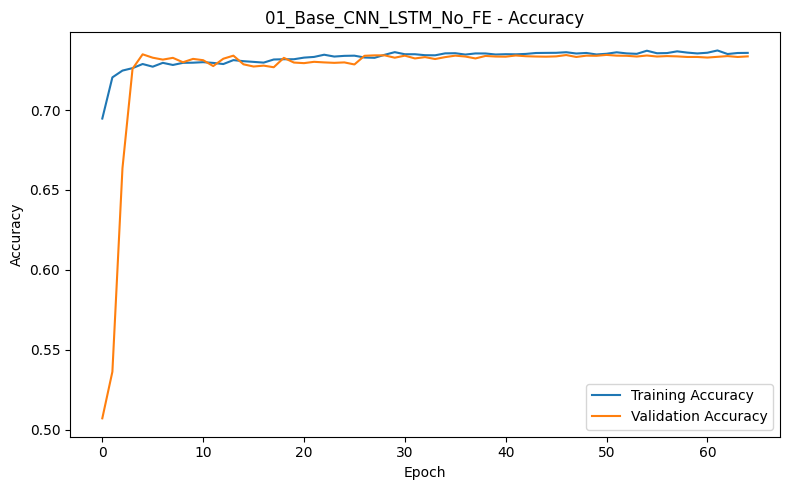

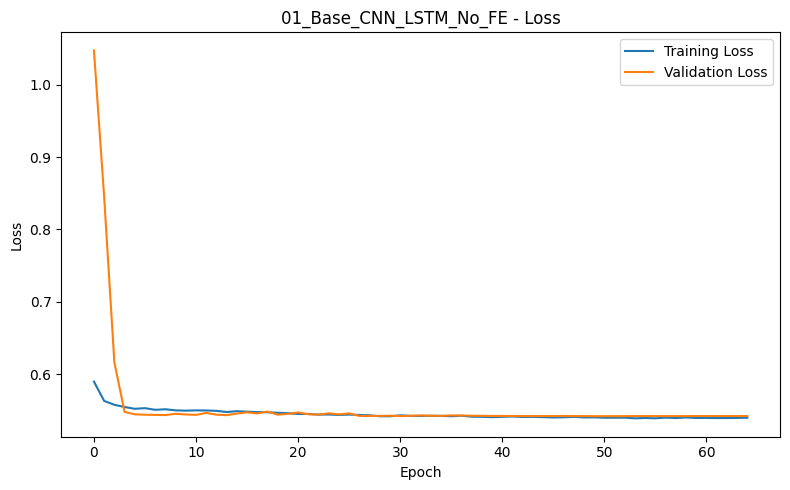

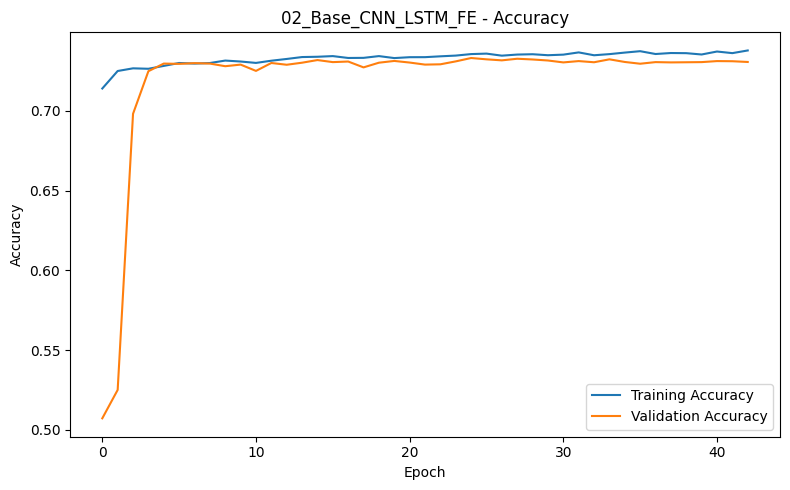

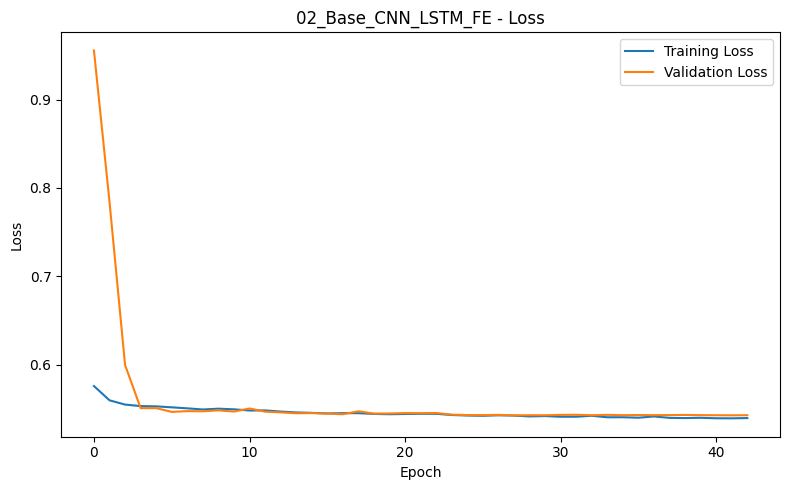

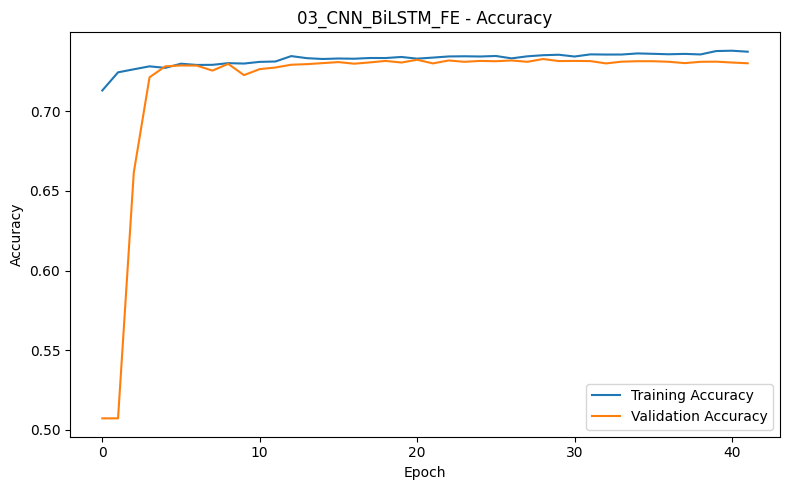

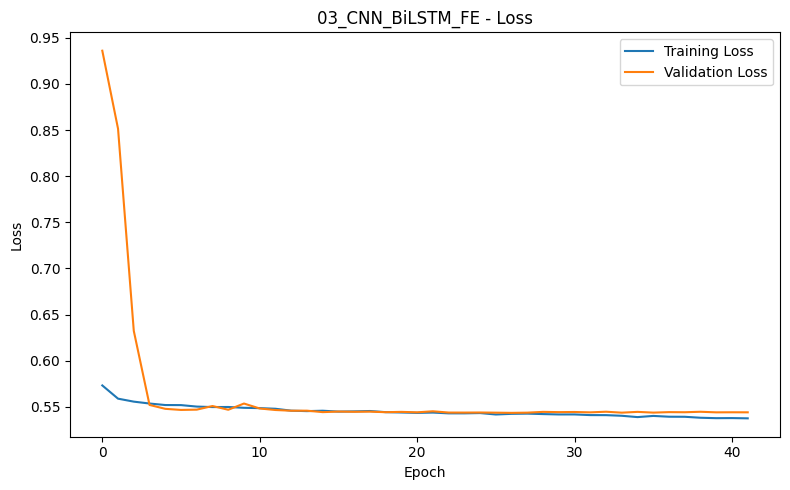

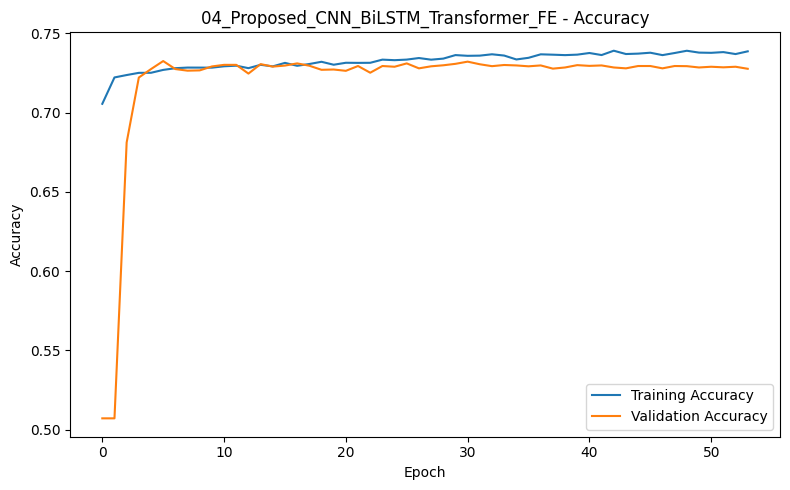

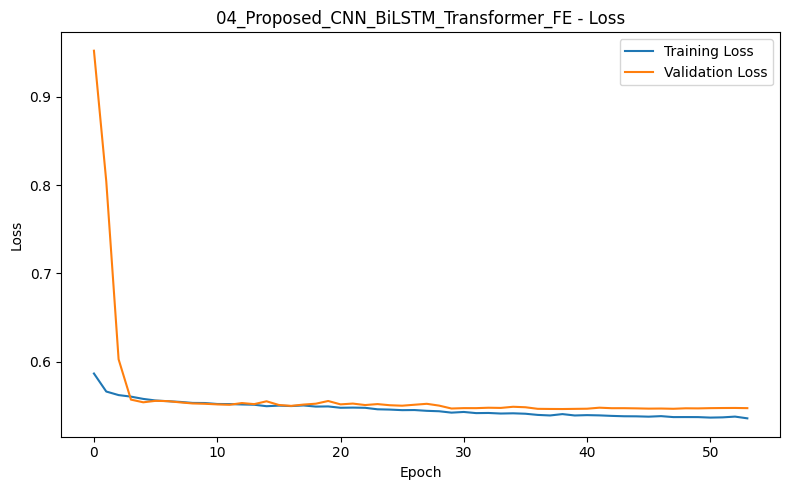

In [ ]:

for name, h in histories.items():
    plt.figure(figsize=(8, 5))
    plt.plot(h["accuracy"], label="Training Accuracy")
    plt.plot(h["val_accuracy"], label="Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(name + " - Accuracy")
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, name + "_accuracy_curve.png"), dpi=300)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(h["loss"], label="Training Loss")
    plt.plot(h["val_loss"], label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(name + " - Loss")
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, name + "_loss_curve.png"), dpi=300)
    plt.show()



In [ ]:

print("\nABLATION LOGIC")
print("1. Base CNN-LSTM vs CNN-LSTM + FE  -> effect of feature engineering")
print("2. CNN-LSTM + FE vs CNN-BiLSTM + FE -> effect of bidirectional sequence modeling")
print("3. CNN-BiLSTM + FE vs CNN-BiLSTM-Transformer + FE -> effect of self-attention")
print("This gives a clean thesis ablation study without changing the dataset.")




ABLATION LOGIC
1. Base CNN-LSTM vs CNN-LSTM + FE  -> effect of feature engineering
2. CNN-LSTM + FE vs CNN-BiLSTM + FE -> effect of bidirectional sequence modeling
3. CNN-BiLSTM + FE vs CNN-BiLSTM-Transformer + FE -> effect of self-attention
This gives a clean thesis ablation study without changing the dataset.


Computing SHAP values...


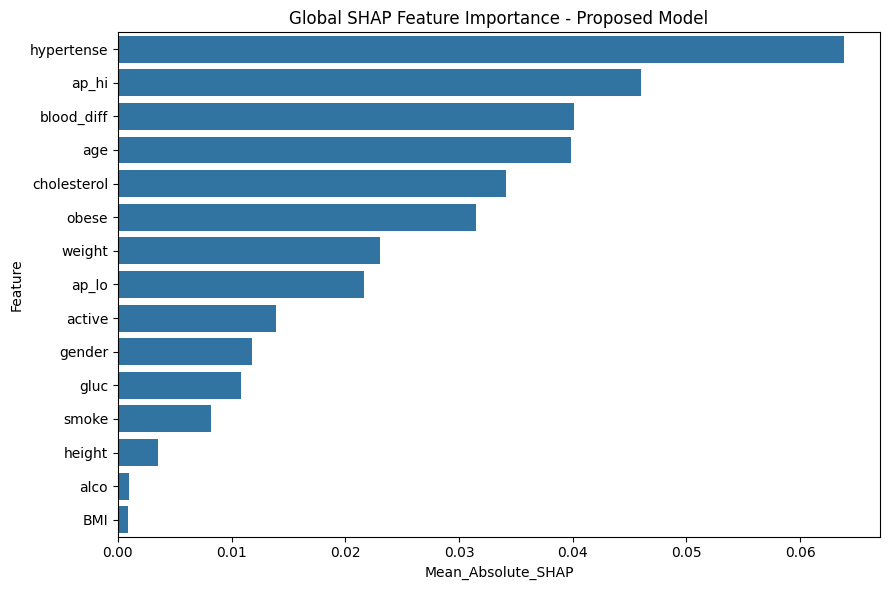


Top SHAP features:


,Feature,Mean_Absolute_SHAP
0,hypertense,0.063826
1,ap_hi,0.045978
2,blood_diff,0.040125
3,age,0.039815
4,cholesterol,0.034122
5,obese,0.031508
6,weight,0.023055
7,ap_lo,0.021659
8,active,0.013932
9,gender,0.011793


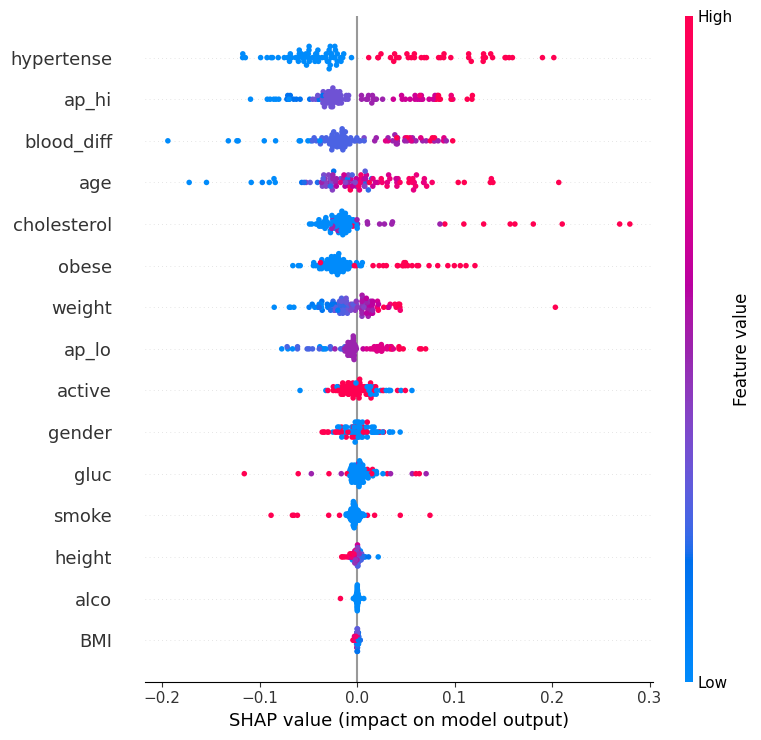

In [ ]:

def run_shap_for_final_model():
    if FINAL_NAME not in trained_models:
        print("Final proposed model not available.")
        return

    model = trained_models[FINAL_NAME]
    Xte, yte, prob, pred, features = test_sets[FINAL_NAME]

    n_bg = min(SHAP_BACKGROUND, len(Xte))
    n_explain = min(SHAP_SAMPLES, len(Xte))

    background = Xte[:n_bg]
    explain_x = Xte[:n_explain]

    print("Computing SHAP values...")
    try:
        explainer = shap.GradientExplainer(model, background)
        shap_values = explainer.shap_values(explain_x)

        if isinstance(shap_values, list):
            shap_values = shap_values[0]

        shap_values = np.asarray(shap_values)

        # Shape can be (N, features, 1) or (N, features, 1, 1).
        shap_values = np.squeeze(shap_values)
        explain_2d = np.squeeze(explain_x)

        if shap_values.ndim == 1:
            shap_values = shap_values.reshape(1, -1)

        if explain_2d.ndim == 1:
            explain_2d = explain_2d.reshape(1, -1)

        # Global importance.
        mean_abs = np.mean(np.abs(shap_values), axis=0)
        order = np.argsort(mean_abs)[::-1]

        shap_df = pd.DataFrame({
            "Feature": np.array(features)[order],
            "Mean_Absolute_SHAP": mean_abs[order]
        })
        shap_df.to_csv(
            os.path.join(OUT_DIR, "proposed_SHAP_feature_importance.csv"),
            index=False
        )

        plt.figure(figsize=(9, 6))
        topn = min(15, len(shap_df))
        sns.barplot(
            data=shap_df.iloc[:topn],
            x="Mean_Absolute_SHAP",
            y="Feature"
        )
        plt.title("Global SHAP Feature Importance - Proposed Model")
        plt.tight_layout()
        plt.savefig(
            os.path.join(OUT_DIR, "SHAP_global_importance.png"),
            dpi=300
        )
        plt.show()

        print("\nTop SHAP features:")
        display(shap_df.head(10))

        # SHAP summary plot.
        shap.summary_plot(
            shap_values,
            explain_2d,
            feature_names=features,
            show=True
        )

    except Exception as e:
        print("SHAP GradientExplainer failed:", repr(e))
        print("The trained model and predictions are still valid.")
        print("You can use the saved model for a model-agnostic SHAP run later.")

if RUN_SHAP:
    run_shap_for_final_model()



In [ ]:

# IMPORTANT:
# With this single cross-sectional Kaggle dataset, this is a
# "clinical-state Digital Twin prototype", NOT a validated real-time
# patient Digital Twin. A true dynamic twin needs repeated/streaming
# patient observations and validation.
#
# This prototype maintains a digital representation of a patient:
# clinical variables + predicted CVD state + risk level.
# New values can be supplied and the twin state can be updated.

RAW_FEATURES_FOR_TWIN = [
    "age","gender","height","weight","ap_hi","ap_lo",
    "cholesterol","gluc","smoke","alco","active"
]

def risk_label(p):
    if p < 0.30:
        return "LOW"
    elif p < 0.60:
        return "MODERATE"
    elif p < 0.80:
        return "HIGH"
    return "VERY HIGH"

def prepare_single_patient(patient_dict, features=FE_FEATURES):
    row = pd.DataFrame([patient_dict]).copy()

    # Convert age if user enters days.
    if row["age"].iloc[0] > 100:
        row["age"] = row["age"] / 365.25

    row["blood_diff"] = row["ap_hi"] - row["ap_lo"]
    row["BMI"] = row["weight"] / ((row["height"] / 100.0) ** 2)
    row["obese"] = (row["BMI"] >= 30).astype(int)
    row["hypertense"] = (
        (row["ap_hi"] >= 140) | (row["ap_lo"] >= 90)
    ).astype(int)

    return row[features].astype(np.float32)

# Load the scaler used by the final model.
final_scaler = joblib.load(
    os.path.join(OUT_DIR, f"{FINAL_NAME}_scaler.pkl")
) if os.path.exists(
    os.path.join(OUT_DIR, f"{FINAL_NAME}_scaler.pkl")
) else None

def predict_twin_state(patient_id, patient_dict):
    if FINAL_NAME not in trained_models:
        raise RuntimeError("Train the proposed model first.")

    Xrow = prepare_single_patient(patient_dict, FE_FEATURES)
    Xscaled = final_scaler.transform(Xrow).astype(np.float32)
    Xseq = Xscaled[..., np.newaxis]

    p = float(
        trained_models[FINAL_NAME].predict(
            Xseq, verbose=0
        )[0][0]
    )

    state = {
        "patient_id": patient_id,
        "clinical_data": patient_dict,
        "predicted_cvd_probability": round(p, 6),
        "risk_level": risk_label(p)
    }
    return state

# Example patient.
example_patient = {
    "age": 55,
    "gender": 1,
    "height": 165,
    "weight": 75,
    "ap_hi": 150,
    "ap_lo": 95,
    "cholesterol": 2,
    "gluc": 1,
    "smoke": 0,
    "alco": 0,
    "active": 1
}

twin_v1 = predict_twin_state("P001", example_patient)
print("\nDIGITAL TWIN - INITIAL STATE")
print(json.dumps(twin_v1, indent=2))

with open(os.path.join(OUT_DIR, "P001_twin_initial.json"), "w") as f:
    json.dump(twin_v1, f, indent=2)




DIGITAL TWIN - INITIAL STATE
{
  "patient_id": "P001",
  "clinical_data": {
    "age": 55,
    "gender": 1,
    "height": 165,
    "weight": 75,
    "ap_hi": 150,
    "ap_lo": 95,
    "cholesterol": 2,
    "gluc": 1,
    "smoke": 0,
    "alco": 0,
    "active": 1
  },
  "predicted_cvd_probability": 0.815281,
  "risk_level": "VERY HIGH"
}


In [ ]:

updated_patient = example_patient.copy()

# Example: updated BP measurement.
updated_patient["ap_hi"] = 135
updated_patient["ap_lo"] = 85

twin_v2 = predict_twin_state("P001", updated_patient)

print("\nDIGITAL TWIN - UPDATED STATE")
print(json.dumps(twin_v2, indent=2))

with open(os.path.join(OUT_DIR, "P001_twin_updated.json"), "w") as f:
    json.dump(twin_v2, f, indent=2)

# Scenario comparison.
comparison = pd.DataFrame([
    {
        "State": "Initial",
        "Systolic_BP": example_patient["ap_hi"],
        "Diastolic_BP": example_patient["ap_lo"],
        "CVD_Probability": twin_v1["predicted_cvd_probability"],
        "Risk_Level": twin_v1["risk_level"]
    },
    {
        "State": "Updated / What-if",
        "Systolic_BP": updated_patient["ap_hi"],
        "Diastolic_BP": updated_patient["ap_lo"],
        "CVD_Probability": twin_v2["predicted_cvd_probability"],
        "Risk_Level": twin_v2["risk_level"]
    }
])

display(comparison)
comparison.to_csv(
    os.path.join(OUT_DIR, "digital_twin_scenario_comparison.csv"),
    index=False
)




DIGITAL TWIN - UPDATED STATE
{
  "patient_id": "P001",
  "clinical_data": {
    "age": 55,
    "gender": 1,
    "height": 165,
    "weight": 75,
    "ap_hi": 135,
    "ap_lo": 85,
    "cholesterol": 2,
    "gluc": 1,
    "smoke": 0,
    "alco": 0,
    "active": 1
  },
  "predicted_cvd_probability": 0.51714,
  "risk_level": "MODERATE"
}


,State,Systolic_BP,Diastolic_BP,CVD_Probability,Risk_Level
0,Initial,150,95,0.815281,VERY HIGH
1,Updated / What-if,135,85,0.517140,MODERATE


In [ ]:

print("\n" + "="*90)
print("THESIS EXPERIMENT COMPLETE")
print("="*90)
print("""
BASELINE:
    CNN -> LSTM -> Dense -> CVD prediction

PROPOSED:
    CNN -> BiLSTM -> Transformer -> Dense -> CVD prediction

EXPERIMENTS:
    - Base CNN-LSTM without feature engineering
    - Base CNN-LSTM with feature engineering
    - CNN-BiLSTM ablation
    - CNN-BiLSTM-Transformer proposed model
    - Accuracy / Precision / Recall / F1
    - ROC-AUC / PR-AUC
    - Confusion matrix
    - Training/validation curves
    - SHAP explainability
    - Clinical-state Digital Twin prototype
    - Digital Twin update / what-if scenario

ALL OUTPUTS ARE SAVED IN:
    /content/cvd_thesis_results
""")

print("\nIMPORTANT FOR YOUR THESIS:")
print("Do NOT write that the proposed model is better unless the measured results show it.")
print("Do NOT claim real-time Digital Twin validation from this static dataset.")
print("Report the actual experimental results produced by this notebook.")



THESIS EXPERIMENT COMPLETE

BASELINE:
    CNN -> LSTM -> Dense -> CVD prediction

PROPOSED:
    CNN -> BiLSTM -> Transformer -> Dense -> CVD prediction

EXPERIMENTS:
    - Base CNN-LSTM without feature engineering
    - Base CNN-LSTM with feature engineering
    - CNN-BiLSTM ablation
    - CNN-BiLSTM-Transformer proposed model
    - Accuracy / Precision / Recall / F1
    - ROC-AUC / PR-AUC
    - Confusion matrix
    - Training/validation curves
    - SHAP explainability
    - Clinical-state Digital Twin prototype
    - Digital Twin update / what-if scenario

ALL OUTPUTS ARE SAVED IN:
    /content/cvd_thesis_results


IMPORTANT FOR YOUR THESIS:
Do NOT write that the proposed model is better unless the measured results show it.
Do NOT claim real-time Digital Twin validation from this static dataset.
Report the actual experimental results produced by this notebook.
